# Effets des différents paramètres sur les indicateurs précédents

In [19]:
import inspect
from datetime import datetime, timedelta

In [20]:
import os
os.makedirs("figs", exist_ok=True)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simmcm2d import sample_datasets, get_kpi

## Etude de sensibilité des paramètres (horizon 1 an):
 - horizon : 1 an = 8760 h
 - n_systems : 200
 - répétitions monte-carlo : 25
 - paramètres baseline : ceux fixés (eta, beta, mu, sigma, etc.)

## 1) baseline numérique + hypothèses

In [22]:
t_max_h = 365 * 24  # 8760 h
n_systems = 2
n_rep = 10

# coûts
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

# paramètres de défaillance (Loi de weibull)
eta = 30 * 24            # 720 h
beta = 3
expiration = 1.1 * eta   # 792 h

# inspections (intervalle ~ normal(mu, sigma))
mu = 7 * 24              # 168 h
sigma = 0.15 * mu        # 25.2 h

# downtime post-failure / temps d’indisponibilité après défaillance
theta = 12               # 12 h

# détecteur
inspection_threshold = 0.5
inspection_deviation = 0.05

# dynamique population
r = 0.0005
nu = 0.00005

param = {
    "eta": eta,
    "beta": beta,
    "expiration": expiration,
    "mu": mu,
    "sigma": sigma,
    "theta": theta,
    "inspection_deviation": inspection_deviation,
    "inspection_threshold": inspection_threshold,
    "r": r,
    "nu": nu,
}

costs = {
    "replacement": cost_replacement,
    "inspection": cost_inspection,
    "component": cost_component,
    "failure": cost_failure,
}

kpi_to_keep = [
    "Average of failure per month",
    "Stability per month",
    "Average of replacement per month",
    "Preventive Effectiveness Ratio (PER)",
    "Précision du détecteur",
    "Taux de détection (Rappel)",
    "Average cost of one system",
    "Standard Deviation",
]


## 2) Utilitaires exécution (wrapper ou enveloppe, signature, sample_datasets)


In [23]:
def _call_sample_datasets(param, costs, n_systems, t_max_h,
                          date_first="2025-01-01 00:00",
                          id_0_component=0, id_0_system=0,
                          output_data_filepath=None):
    """
    appelle sample_datasets en s'adaptant à sa signature.

    cas supportés:
    - sample_datasets(..., t_max=...) ou t_max_h
    - sample_datasets(..., date_first=..., date_final=...)
    - + paramètres optionnels (id_0_component, id_0_system, output_data_filepath)
    """
    sig = inspect.signature(sample_datasets)
    params = sig.parameters

    kwargs = {}

    # n_systems
    if "n_systems" in params:
        kwargs["n_systems"] = n_systems
    elif "n" in params:
        kwargs["n"] = n_systems  # au cas où
    else:
        # si ta fonction ne prend pas n_systems en kwargs, on tentera en positionnel
        pass

    # horizon
    # 1) t_max / t_max_h
    if "t_max_h" in params:
        kwargs["t_max_h"] = t_max_h
    elif "t_max" in params:
        kwargs["t_max"] = t_max_h
    else:
        # 2) date_first/date_final (comme dans simulator_example.ipynb)
        if "date_first" in params and "date_final" in params:
            # calcule date_final = date_first + t_max_h heures
            dt0 = datetime.fromisoformat(date_first)
            dtf = dt0 + timedelta(hours=float(t_max_h))
            kwargs["date_first"] = dt0.strftime("%Y-%m-%d %H:%M")
            kwargs["date_final"] = dtf.strftime("%Y-%m-%d %H:%M")

    # ids de départ
    if "id_0_component" in params:
        kwargs["id_0_component"] = id_0_component
    if "id_0_system" in params:
        kwargs["id_0_system"] = id_0_system

    # optionnel: output csv si la fonction le supporte
    if output_data_filepath is not None and "output_data_filepath" in params:
        kwargs["output_data_filepath"] = output_data_filepath

    # appel: si n_systems n'est pas en kwargs, on essaie en positionnel proprement
    try:
        return sample_datasets(param, costs, **kwargs)
    except TypeError:
        # fallback positionnel (param, costs, n_systems, ...)
        return sample_datasets(param, costs, n_systems, **kwargs)

In [24]:
def run_once(param, costs, seed=None,
             n_systems=n_systems, t_max_h=t_max_h,
             date_first="2025-01-01 00:00",
             output_data_filepath=None):
    """
    lance 1 simulation et renvoie (df, kpi_dict)
    """
    if seed is not None:
        np.random.seed(seed)

    df = _call_sample_datasets(
        param=param,
        costs=costs,
        n_systems=n_systems,
        t_max_h=t_max_h,
        date_first=date_first,
        id_0_component=0,
        id_0_system=0,
        output_data_filepath=output_data_filepath,
    )

    kpi = get_kpi(df, costs)
    return df, kpi


def run_mc(param, costs, n_rep=n_rep, base_seed=1234, **kwargs):
    """
    répète n_rep fois, retourne:
      - mean_kpi: dict kpi -> moyenne
      - std_kpi : dict kpi -> écart-type
      - raw     : dataframe des kpi par réplication
    """
    rows = []
    for i in range(int(n_rep)):
        seed = int(base_seed) + i
        _, kpi = run_once(param, costs, seed=seed, **kwargs)
        row = {k: kpi.get(k, np.nan) for k in kpi_to_keep}
        rows.append(row)

    raw = pd.DataFrame(rows)
    mean_kpi = raw.mean(numeric_only=True).to_dict()
    std_kpi = raw.std(numeric_only=True, ddof=1).to_dict()
    return mean_kpi, std_kpi, raw

## 3) Sweeps 1d + plots




In [25]:

def sweep_1d(param_base, costs, key, grid, n_rep=n_rep, base_seed=1234, **kwargs):
    """
    balayage 1d d'un paramètre -> dataframe avec moyenne/std des kpi
    """
    records = []
    for j, val in enumerate(grid):
        p = dict(param_base)
        p[key] = float(val)

        mean_kpi, std_kpi, _ = run_mc(
            p, costs,
            n_rep=n_rep,
            base_seed=base_seed + 1000 * j,
            **kwargs
        )

        rec = {"param": key, "value": float(val)}
        for k in kpi_to_keep:
            rec[f"{k}__mean"] = mean_kpi.get(k, np.nan)
            rec[f"{k}__std"] = std_kpi.get(k, np.nan)
        records.append(rec)

    return pd.DataFrame(records)


def plot_kpi_vs(df_sweep, kpis=None, title=None, x_label=None, savepath=None):
    """
    plots kpi(mean) vs value avec barres d'erreur = std
    """
    if kpis is None:
        kpis = [
            "Average of failure per month",
            "Stability per month",
            "Average cost of one system",
            "Précision du détecteur",
            "Taux de détection (Rappel)",
            "Preventive Effectiveness Ratio (PER)",
        ]

    x = df_sweep["value"].values

    n = len(kpis)
    fig, axes = plt.subplots(n, 1, figsize=(8, 3.5 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, kpi in zip(axes, kpis):
        y = df_sweep[f"{kpi}__mean"].values
        yerr = df_sweep[f"{kpi}__std"].values
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
        ax.set_ylabel(kpi)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(x_label if x_label else df_sweep["param"].iloc[0])

    if title is not None:
        fig.suptitle(title)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


## 4) Interactions 2d (heatmaps)

In [26]:
# ============================================================

# ============================================================

def sweep_2d(param_base, costs, key_x, grid_x, key_y, grid_y, kpi_name,
             n_rep=n_rep, base_seed=1234, **kwargs):
    """
    retourne une matrice z (len(grid_y), len(grid_x)) des kpi moyens
    """
    z = np.zeros((len(grid_y), len(grid_x)), dtype=float)

    for iy, vy in enumerate(grid_y):
        for ix, vx in enumerate(grid_x):
            p = dict(param_base)
            p[key_x] = float(vx)
            p[key_y] = float(vy)

            mean_kpi, _, _ = run_mc(
                p, costs,
                n_rep=n_rep,
                base_seed=base_seed + 1000 * iy + 10 * ix,
                **kwargs
            )
            z[iy, ix] = mean_kpi.get(kpi_name, np.nan)

    return z


def plot_heatmap(z, x_ticks, y_ticks, xlabel, ylabel, title, cbar_label=None, savepath=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(z, aspect="auto", origin="lower")
    cbar = fig.colorbar(im, ax=ax, label=cbar_label or title)

    ax.set_xticks(np.arange(len(x_ticks)))
    ax.set_xticklabels([str(x) for x in x_ticks], rotation=45)

    ax.set_yticks(np.arange(len(y_ticks)))
    ax.set_yticklabels([str(y) for y in y_ticks])

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

## 5) Exécution



In [27]:
# --- simple verication du bon fonctionnement ---
mean0, std0, raw0 = run_mc(param, costs)
baseline_summary = pd.DataFrame({"mean": mean0, "std": std0}).sort_index()
print(baseline_summary)

                                              mean          std
Average cost of one system            28690.000000  5998.231221
Average of failure per month              1.197500     0.126084
Average of replacement per month          1.322727     0.165638
Preventive Effectiveness Ratio (PER)      1.112144     0.155635
Précision du détecteur                    0.800000     0.141185
Stability per month                       0.554093     0.200870
Standard Deviation                    12940.054096   500.000000
Taux de détection (Rappel)                0.323000     0.098099


                  param  value  Average of failure per month__mean  \
0  inspection_threshold    0.1                            1.268333   
1  inspection_threshold    0.2                            1.025000   
2  inspection_threshold    0.3                            1.318929   
3  inspection_threshold    0.4                            1.326905   
4  inspection_threshold    0.5                            1.427579   
5  inspection_threshold    0.6                            1.300000   
6  inspection_threshold    0.7                            1.170952   
7  inspection_threshold    0.8                            1.298056   
8  inspection_threshold    0.9                            1.431338   

   Average of failure per month__std  Stability per month__mean  \
0                           0.316857                   0.660376   
1                           0.079057                   0.549871   
2                           0.223859                   0.641688   
3                           0.2

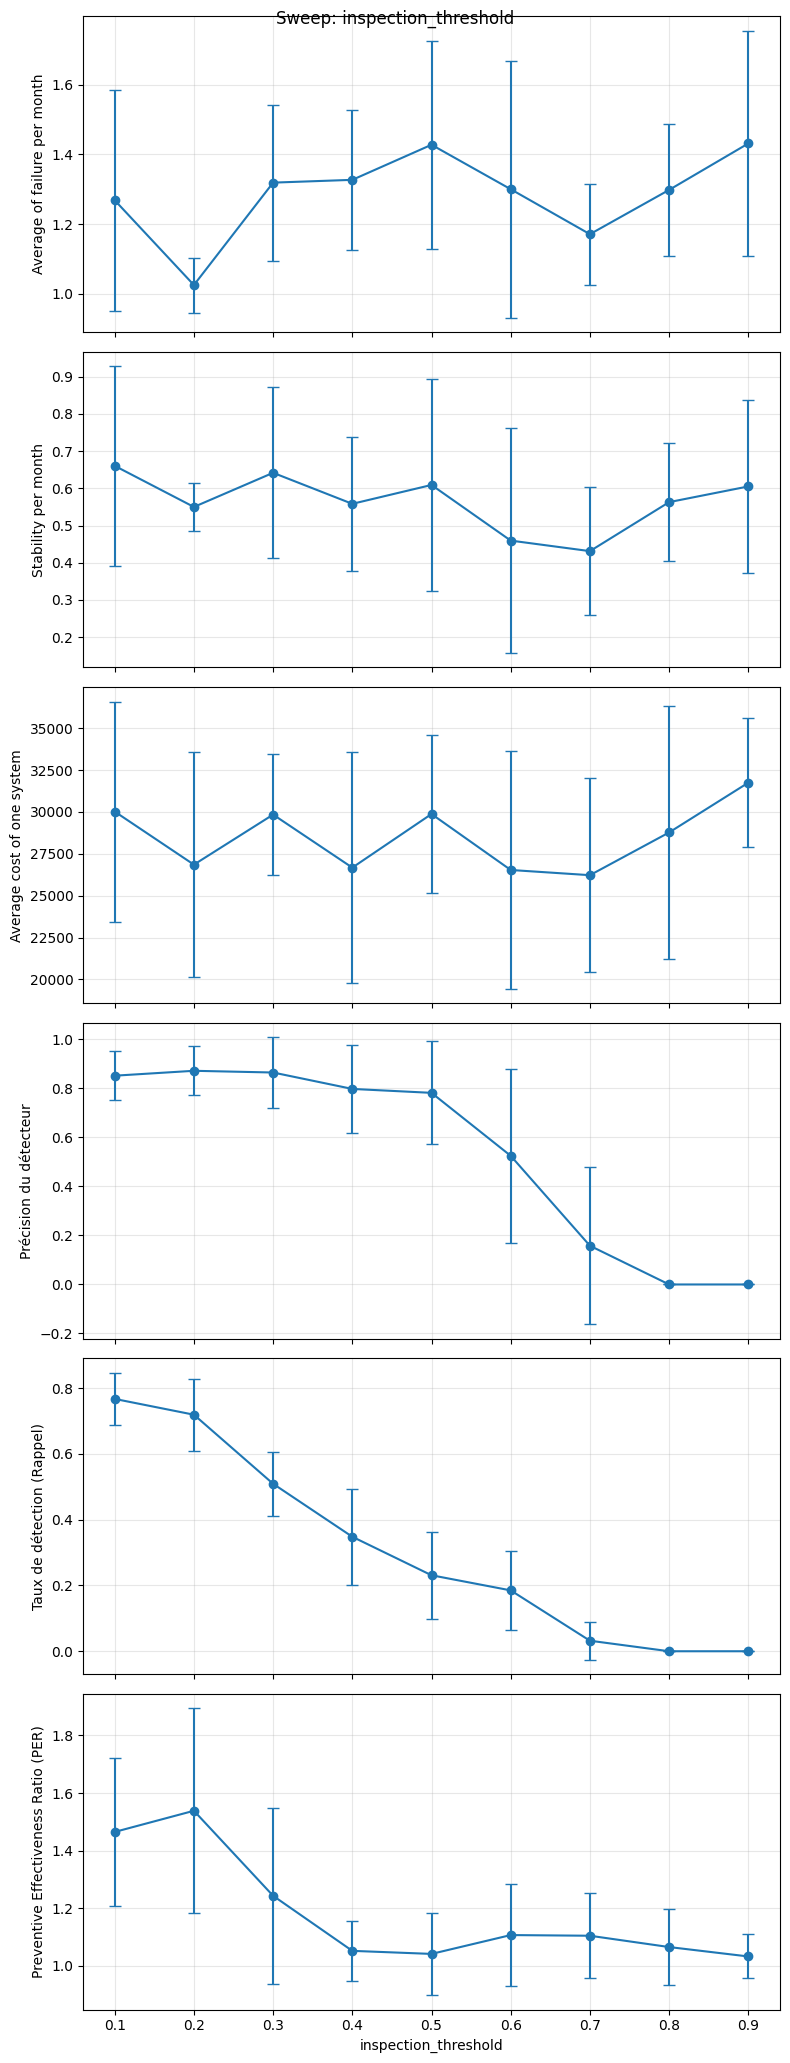

In [28]:
# --- sweeps 1d ---
threshold_grid = np.linspace(0.1, 0.9, 9)
df_thr = sweep_1d(param, costs, "inspection_threshold", threshold_grid)
print(df_thr)
plot_kpi_vs(
    df_thr,
    title="Sweep: inspection_threshold",
    savepath="figs/sweep_threshold.png"
)

  param  value  Average of failure per month__mean  \
0    mu   72.0                            1.118571   
1    mu  120.0                            1.288810   
2    mu  168.0                            1.372024   
3    mu  240.0                            1.296843   
4    mu  336.0                            1.389740   

   Average of failure per month__std  Stability per month__mean  \
0                           0.130799                   0.423269   
1                           0.199461                   0.461539   
2                           0.286152                   0.567407   
3                           0.165897                   0.580758   
4                           0.252455                   0.530781   

   Stability per month__std  Average of replacement per month__mean  \
0                  0.061638                                1.225000   
1                  0.181687                                1.278788   
2                  0.227757                                

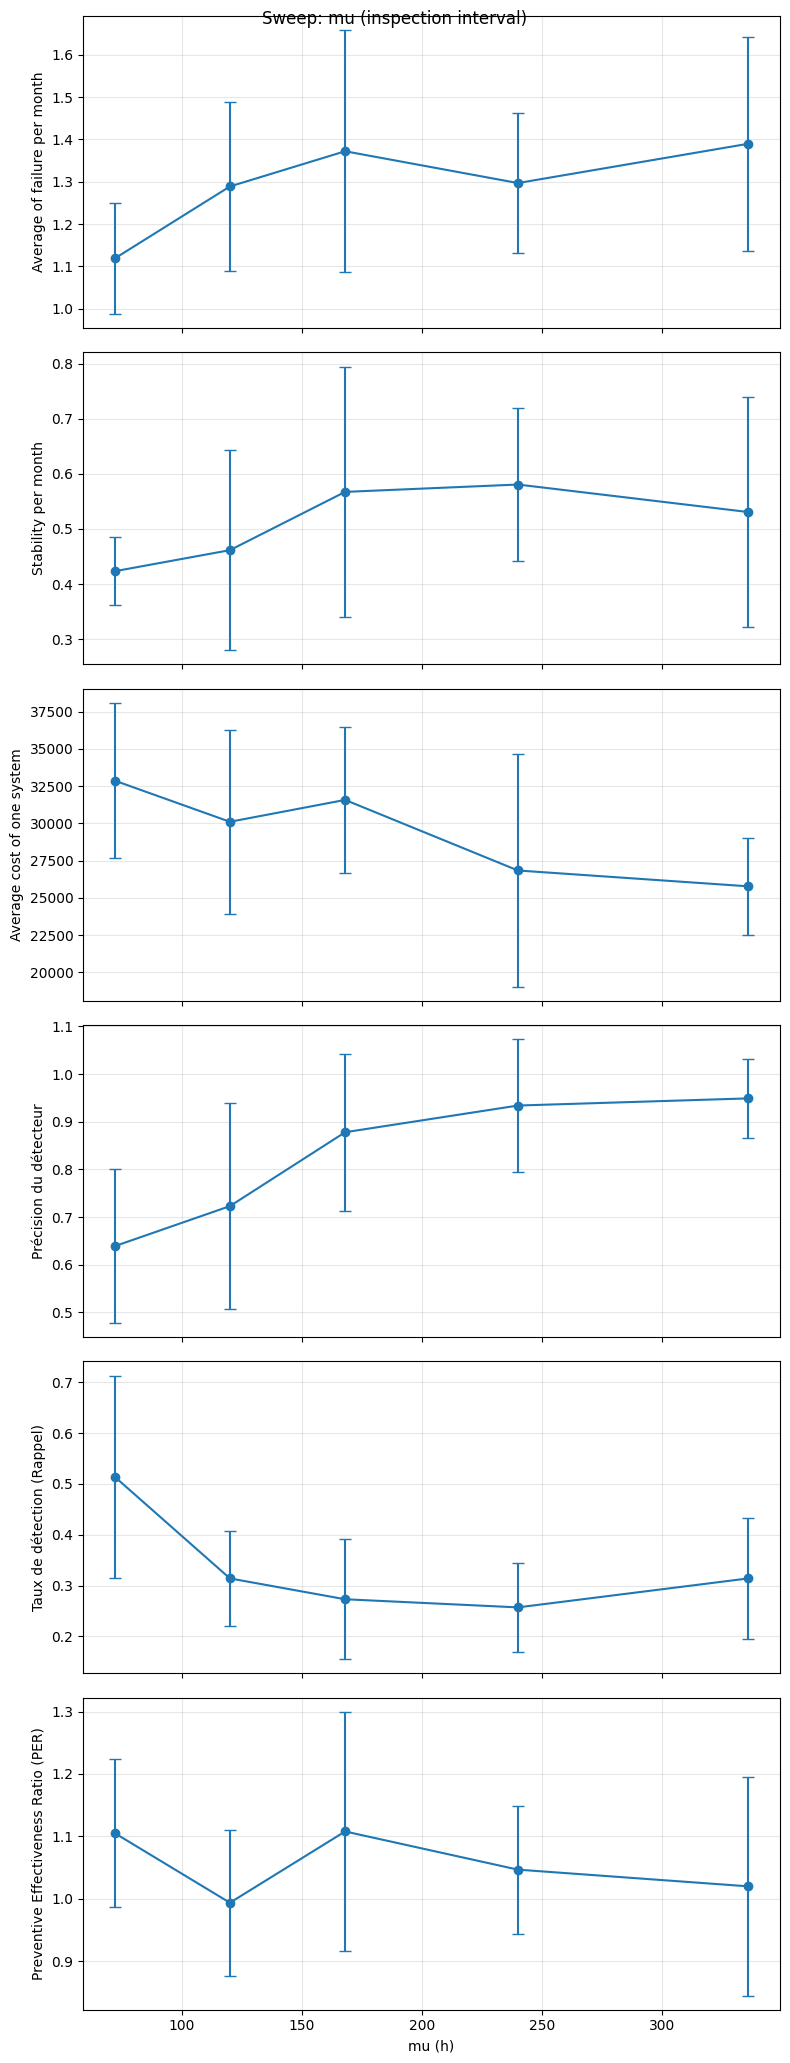

In [30]:
mu_grid = np.array([72, 120, 168, 240, 336], dtype=float)
df_mu = sweep_1d(param, costs, "mu", mu_grid)
print(df_mu)
plot_kpi_vs(
    df_mu,
    title="Sweep: mu (inspection interval)",
    x_label="mu (h)",
    savepath="figs/sweep_mu.png"
)

                  param     value  Average of failure per month__mean  \
0  inspection_deviation  0.000001                            1.243200   
1  inspection_deviation  0.020000                            1.287540   
2  inspection_deviation  0.050000                            1.372024   
3  inspection_deviation  0.080000                            1.311071   
4  inspection_deviation  0.120000                            1.358831   
5  inspection_deviation  0.160000                            1.340238   
6  inspection_deviation  0.200000                            1.208452   

   Average of failure per month__std  Stability per month__mean  \
0                           0.194553                   0.528194   
1                           0.314627                   0.517949   
2                           0.286152                   0.567407   
3                           0.192255                   0.540863   
4                           0.298540                   0.600177   
5            

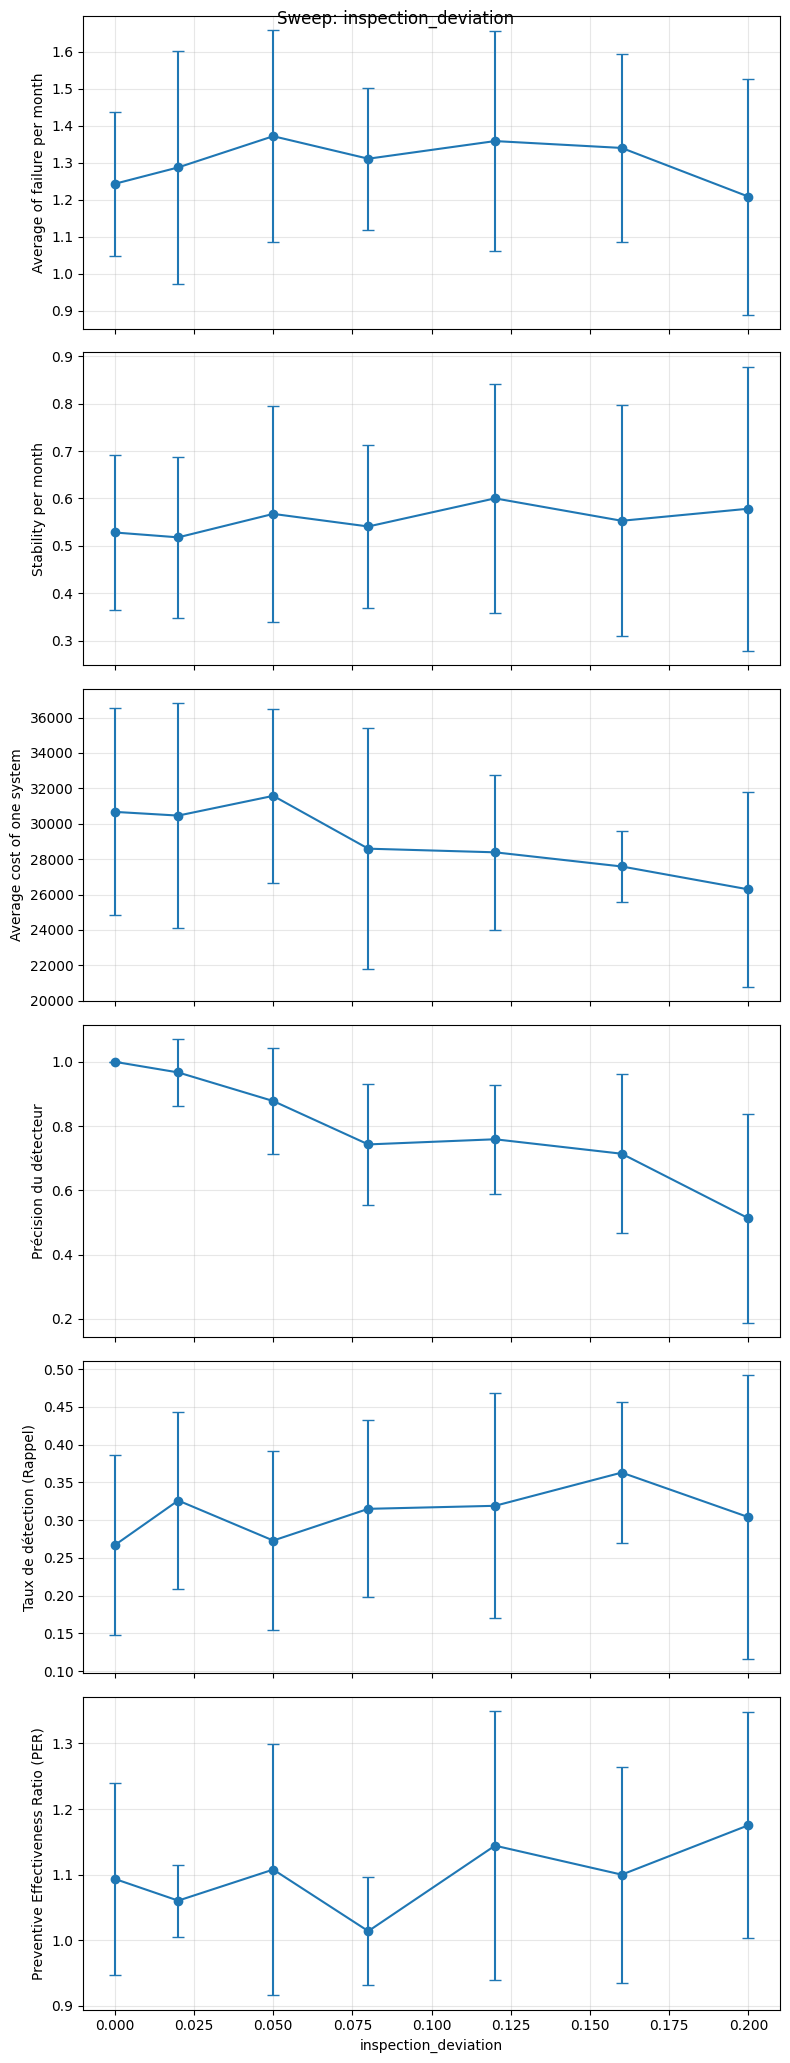

In [31]:
dev_grid = np.array([1e-6, 0.02, 0.05, 0.08, 0.12, 0.16, 0.20], dtype=float)
df_dev = sweep_1d(param, costs, "inspection_deviation", dev_grid)
print(df_dev)
plot_kpi_vs(
    df_dev,
    title="Sweep: inspection_deviation",
    savepath="figs/sweep_deviation.png"
)

   param  value  Average of failure per month__mean  \
0  sigma    8.4                            1.155833   
1  sigma   16.8                            1.259722   
2  sigma   25.2                            1.372024   
3  sigma   42.0                            1.336071   
4  sigma   58.8                            1.291209   

   Average of failure per month__std  Stability per month__mean  \
0                           0.080171                   0.446607   
1                           0.139060                   0.467195   
2                           0.286152                   0.567407   
3                           0.234135                   0.544608   
4                           0.249029                   0.554922   

   Stability per month__std  Average of replacement per month__mean  \
0                  0.102093                                1.264697   
1                  0.144721                                1.291667   
2                  0.227757                          

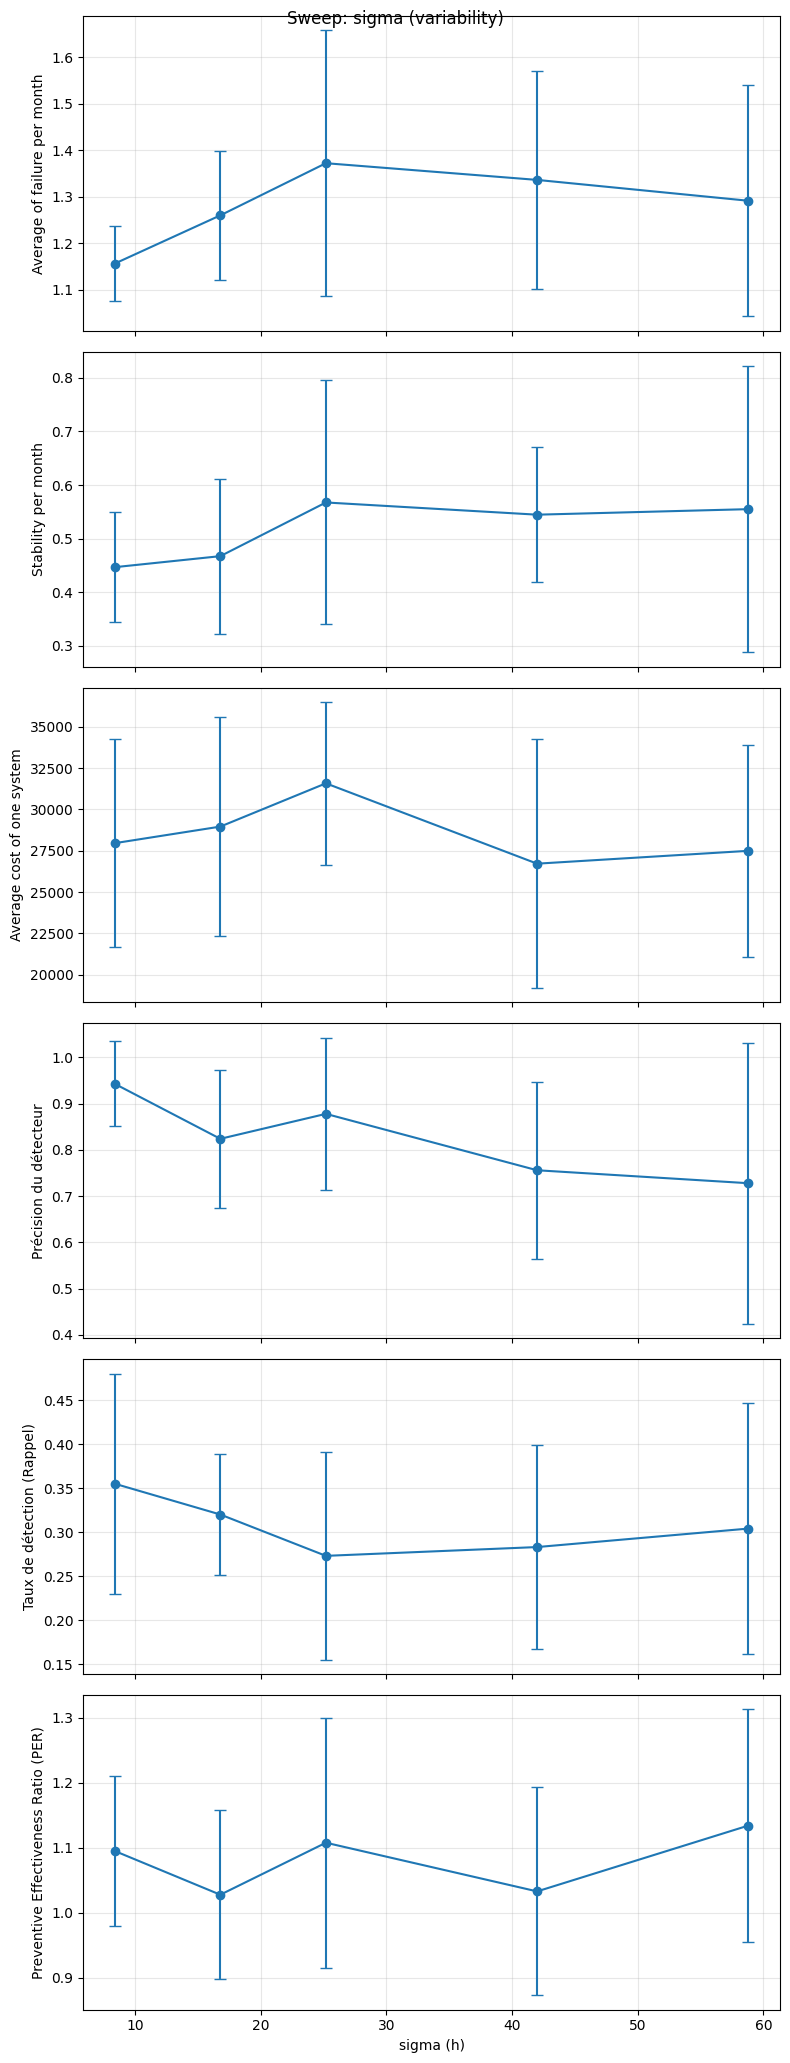

In [32]:
k_grid = np.array([0.05, 0.10, 0.15, 0.25, 0.35], dtype=float)
sigma_grid = k_grid * param["mu"]
df_sig = sweep_1d(param, costs, "sigma", sigma_grid)
df_sig = df_sig.assign(k=k_grid)
print(df_sig)
plot_kpi_vs(
    df_sig,
    title="Sweep: sigma (variability)",
    x_label="sigma (h)",
    savepath="figs/sweep_sigma.png"
)

/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: invalid value encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: invalid value encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop

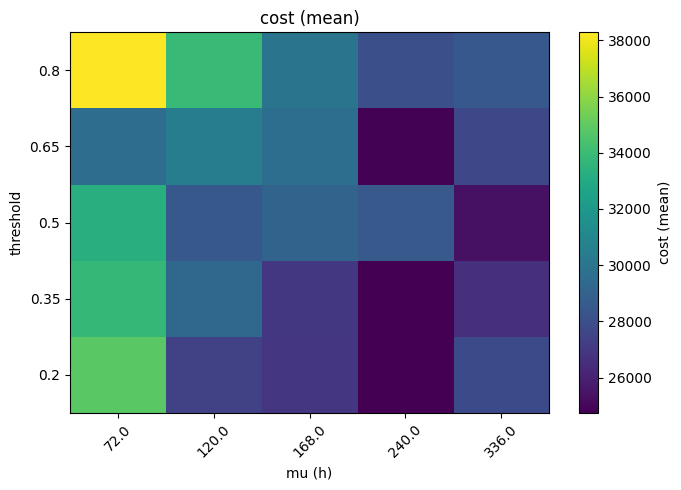

/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: invalid value encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: invalid value encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: invalid value encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop

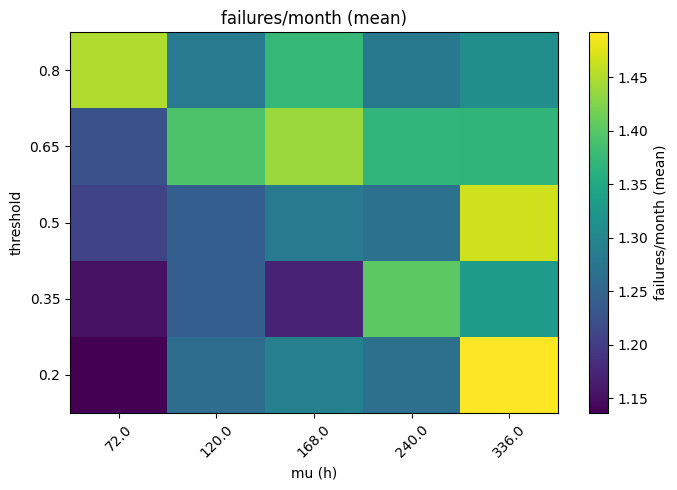

In [33]:
# --- heatmaps 2d ---
mu_grid2 = np.array([72, 120, 168, 240, 336], dtype=float)
thr_grid2 = np.array([0.2, 0.35, 0.5, 0.65, 0.8], dtype=float)

z_cost = sweep_2d(
    param, costs,
    "mu", mu_grid2,
    "inspection_threshold", thr_grid2,
    kpi_name="Average cost of one system"
)
plot_heatmap(
    z_cost, mu_grid2, thr_grid2,
    "mu (h)", "threshold", "cost (mean)",
    savepath="figs/heatmap_cost.png"
)

z_fail = sweep_2d(
    param, costs,
    "mu", mu_grid2,
    "inspection_threshold", thr_grid2,
    kpi_name="Average of failure per month"
)
plot_heatmap(
    z_fail, mu_grid2, thr_grid2,
    "mu (h)", "threshold", "failures/month (mean)",
    savepath="figs/heatmap_failures.png"
)

/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/De

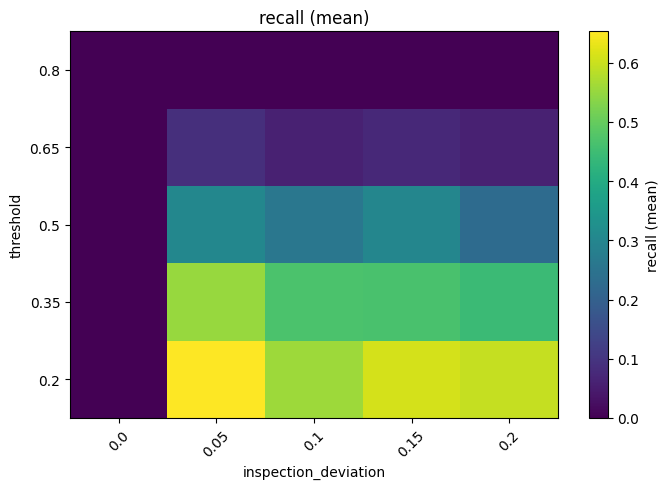

/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/Desktop/Projet_collectif/ProjetM2D2526/simmcm2d/simmcm2d/classes.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
/Users/dialloamadou/De

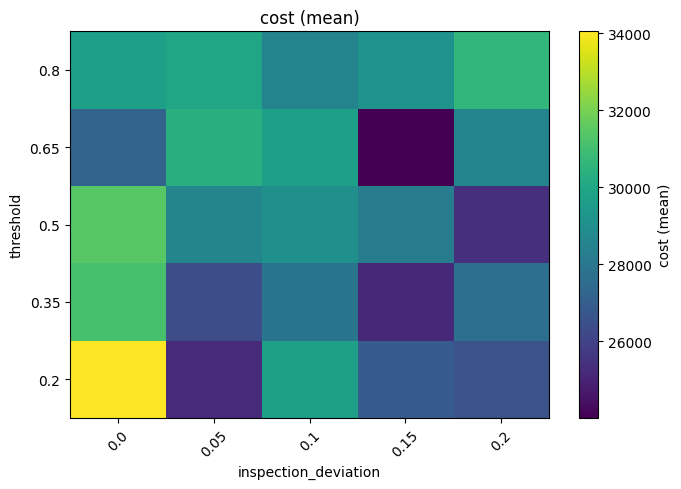

In [34]:
dev_grid2 = np.array([0.00, 0.05, 0.10, 0.15, 0.20], dtype=float)
thr_grid2b = np.array([0.2, 0.35, 0.5, 0.65, 0.8], dtype=float)

z_rec = sweep_2d(
    param, costs,
    "inspection_deviation", dev_grid2,
    "inspection_threshold", thr_grid2b,
    kpi_name="Taux de détection (Rappel)"
)
plot_heatmap(
    z_rec, dev_grid2, thr_grid2b,
    "inspection_deviation", "threshold", "recall (mean)",
    savepath="figs/heatmap_recall.png"
)

z_cost2 = sweep_2d(
    param, costs,
    "inspection_deviation", dev_grid2,
    "inspection_threshold", thr_grid2b,
    kpi_name="Average cost of one system"
)
plot_heatmap(
    z_cost2, dev_grid2, thr_grid2b,
    "inspection_deviation", "threshold", "cost (mean)",
    savepath="figs/heatmap_cost_deviation_threshold.png"
)

In [35]:
beta_grid = [1.5, 2.0, 3.0, 4.0]
all_beta = []
for b in beta_grid:
    p = dict(param)
    p["beta"] = float(b)
    df_b = sweep_1d(p, costs, "inspection_threshold", threshold_grid, n_rep=15)
    df_b["beta"] = float(b)
    all_beta.append(df_b)
df_beta = pd.concat(all_beta, ignore_index=True)
print(df_beta.head())


                  param  value  Average of failure per month__mean  \
0  inspection_threshold    0.1                            1.572302   
1  inspection_threshold    0.2                            1.407857   
2  inspection_threshold    0.3                            1.407549   
3  inspection_threshold    0.4                            1.360106   
4  inspection_threshold    0.5                            1.445926   

   Average of failure per month__std  Stability per month__mean  \
0                           0.401492                   1.082779   
1                           0.248278                   0.663011   
2                           0.197183                   0.812879   
3                           0.206412                   0.668661   
4                           0.471528                   0.753677   

   Stability per month__std  Average of replacement per month__mean  \
0                  0.630926                                3.216667   
1                  0.228660       

In [36]:
# --- exports csv ---
df_thr.to_csv("results_sweep_threshold.csv", index=False)
df_mu.to_csv("results_sweep_mu.csv", index=False)
df_dev.to_csv("results_sweep_deviation.csv", index=False)
df_sig.to_csv("results_sweep_sigma.csv", index=False)
print("exports effectués ✅")

exports effectués ✅
